# What is MINIST ?

**MINIST - Modified National Institute of Standards and Technology**

* It is a dataset of handwritten digits (0–9) used for training and testing models in Machine Learning and Deep Learning.

# **LIBRARIES:**

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix


# **Load MNIST Dataset:**

In [5]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train Data Shape:", X_train.shape)
print("Test Data Shape:", X_test.shape)
print("Train Labels Shape:", y_train.shape)
print("Test Labels Shape:", y_test.shape)
print("Total Classes:", len(np.unique(y_train)))

Train Data Shape: (60000, 28, 28)
Test Data Shape: (10000, 28, 28)
Train Labels Shape: (60000,)
Test Labels Shape: (10000,)
Total Classes: 10


# **Data Preprocessing:**

In [6]:
# 1. Normalize pixel values (0-255 to 0-1)

X_train = X_train / 255.0
X_test = X_test / 255.0

In [7]:
# 2. Reshape for CNN (add channel dimension)

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [8]:
# 3. One-Hot Encoding for labels

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [9]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train_cat shape:", y_train_cat.shape)
print("Label Example:", y_train[0], "->", y_train_cat[0])

X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)
y_train_cat shape: (60000, 10)
Label Example: 5 -> [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


#**Build CNN Model:**

In [10]:
model = Sequential()

# Block 1 - First Convolution

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))   # extract feature
model.add(MaxPooling2D(2,2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Block 2 - Second Convolution

model.add(Conv2D(64, (3,3), activation='relu'))         # apply filter and reduce the size of the img
model.add(MaxPooling2D(2,2))

In [12]:
# Block 3 - Third Convolution

model.add(Conv2D(64, (3,3), activation='relu'))

In [13]:
# Flatten & Dense Layers

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

In [14]:
# Compile

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,890 (511.29 KB)

 Trainable params: 130,890 (511.29 KB)

 Non-trainable params: 0 (0.00 B)

None


# **Train CNN Model**:


In [15]:
history = model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

print("Training Complete!")

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 51s 52ms/step - accuracy: 0.9277 - loss: 0.2330 - val_accuracy: 0.9821 - val_loss: 0.0518
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.9807 - loss: 0.0672 - val_accuracy: 0.9888 - val_loss: 0.0320
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 51ms/step - accuracy: 0.9857 - loss: 0.0478 - val_accuracy: 0.9893 - val_loss: 0.0332
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - accuracy: 0.9890 - loss: 0.0384 - val_accuracy: 0.9925 - val_loss: 0.0244
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 52ms/step - accuracy: 0.9899 - loss: 0.0328 - val_accuracy: 0.9907 - val_loss: 0.0278
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 51ms/step - accuracy: 0.9922 - loss: 0.0263 - val_accuracy: 0.9908 - val_loss: 0.0283
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 51ms/step - accuracy: 0.9937 - loss: 0.0218 - val_accuracy: 0.9919 - val_loss: 0.0269
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 51ms/step - accuracy: 0.9934 - loss: 0.0205 - 

# **Evaluate Model Accuracy**:


In [16]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 99.09%
Test Loss: 0.0296


#**Accuracy Visualization:**

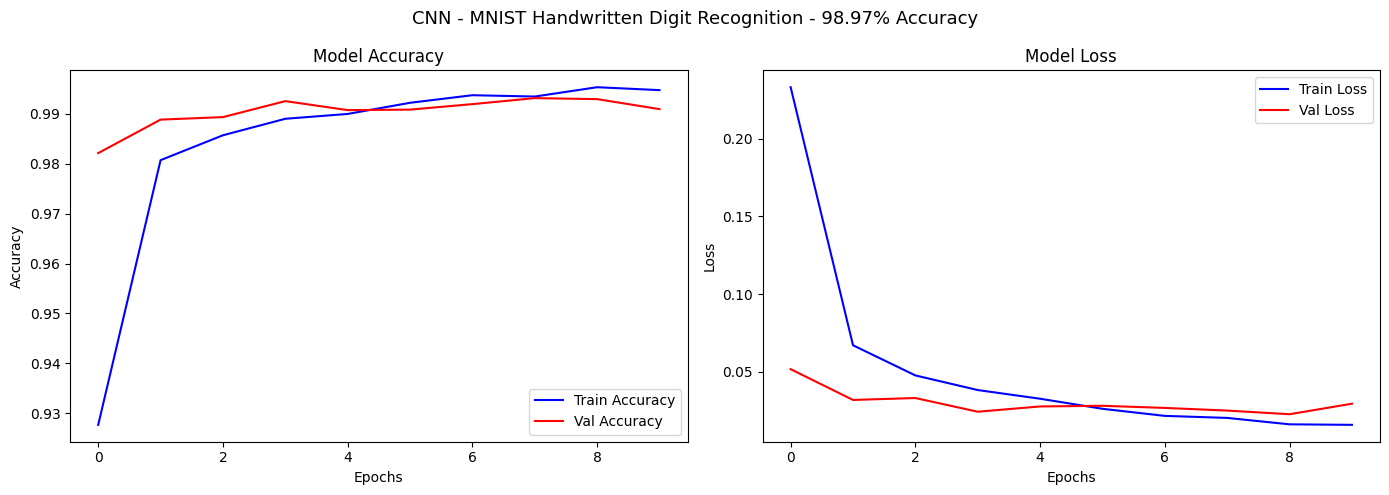

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Accuracy Plot
axes[0].plot(history.history['accuracy'], color='blue', label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], color='red', label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# 2. Loss Plot
axes[1].plot(history.history['loss'], color='blue', label='Train Loss')
axes[1].plot(history.history['val_loss'], color='red', label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('CNN - MNIST Handwritten Digit Recognition - 98.97% Accuracy', fontsize=13)
plt.tight_layout()
plt.show()

# **Confusion Matrix:**

In [18]:
y_pred = model.predict(X_test)               # before - numerical  |  now - img | pred   | y_pred , y_test
y_pred_classes = np.argmax(y_pred, axis=1)   # append - 1 | extend - multi

cm = confusion_matrix(y_test, y_pred_classes)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


#**Confusion Matrix Visualization:**

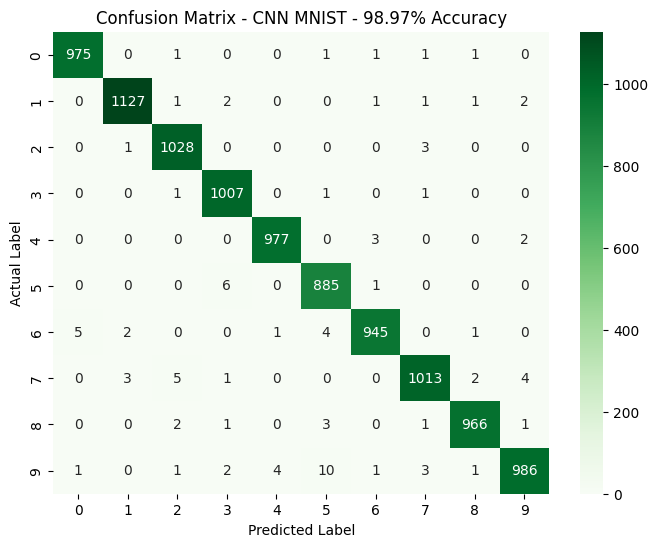

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=range(10),
            yticklabels=range(10))
plt.title('Confusion Matrix - CNN MNIST - 98.97% Accuracy')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

print(classification_report(y_test, y_pred_classes))

# **Show Sample Predictions:**

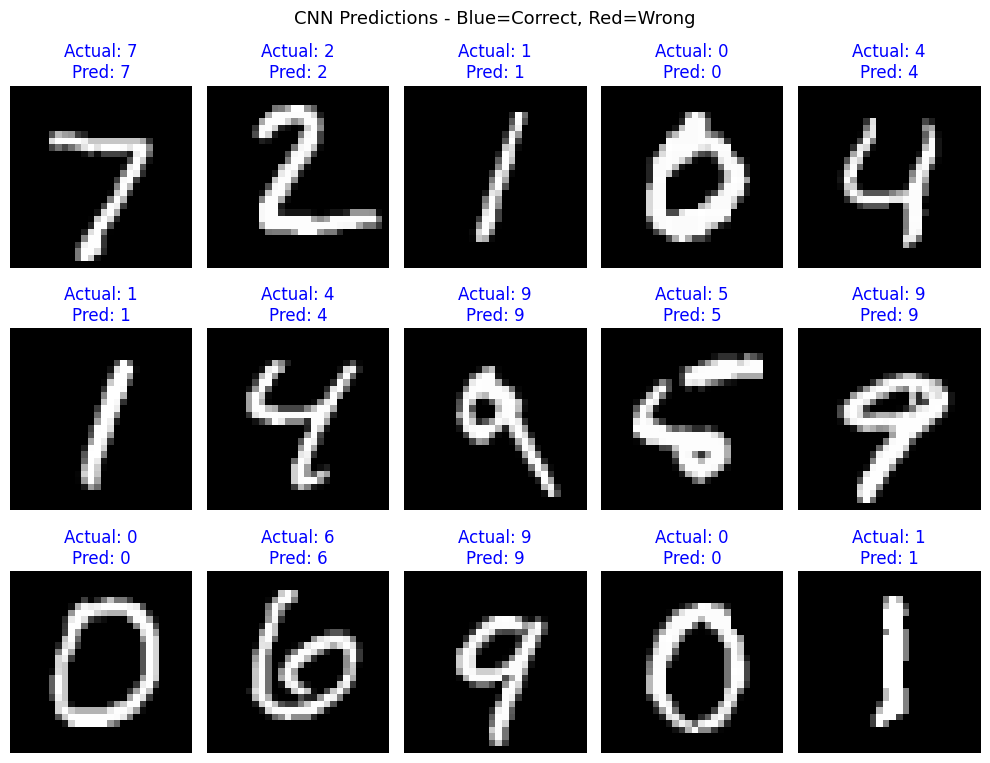

In [20]:
fig, axes = plt.subplots(3, 5, figsize=(10, 8))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    actual = y_test[i]
    predicted = y_pred_classes[i]
    color = 'blue' if actual == predicted else 'red'
    ax.set_title(f"Actual: {actual}\nPred: {predicted}", color=color)
    ax.axis('off')

plt.suptitle('CNN Predictions - Blue=Correct, Red=Wrong', fontsize=13)
plt.tight_layout()
plt.show()

# Multipule Value In One Frame :

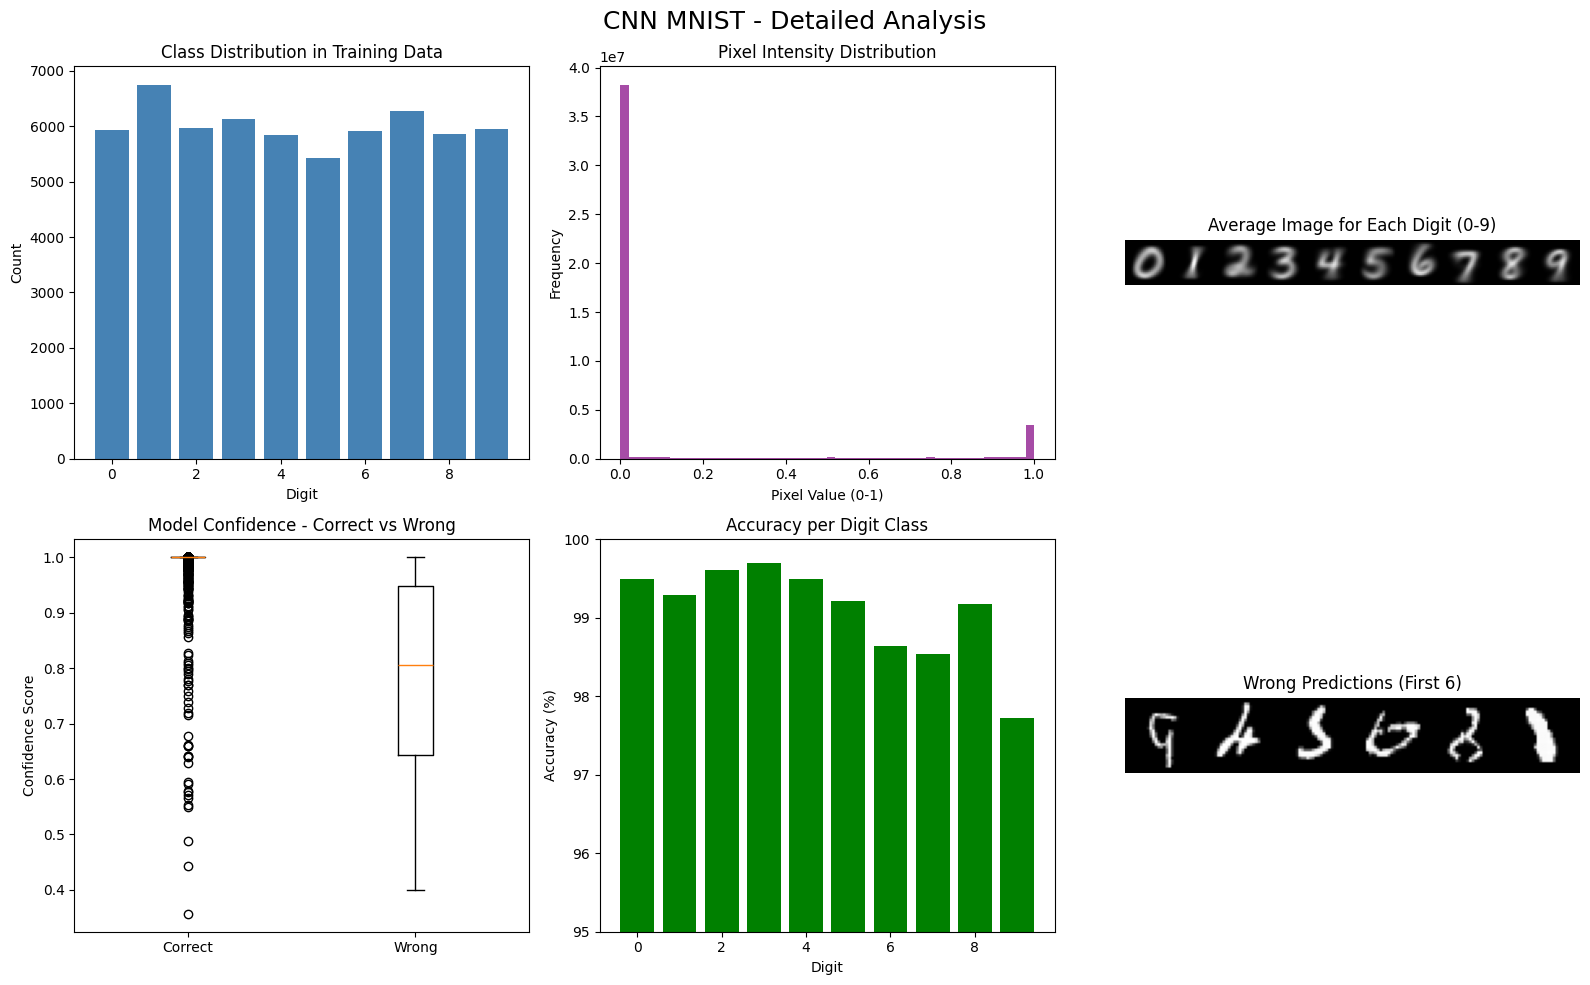

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Class Distribution - Bar Plot
class_counts = np.bincount(y_train)
axes[0,0].bar(range(10), class_counts, color='steelblue')
axes[0,0].set_title('Class Distribution in Training Data')
axes[0,0].set_xlabel('Digit')
axes[0,0].set_ylabel('Count')

# 2. Pixel Intensity Distribution - Histogram
axes[0,1].hist(X_train.flatten(), bins=50, color='purple', alpha=0.7)
axes[0,1].set_title('Pixel Intensity Distribution')
axes[0,1].set_xlabel('Pixel Value (0-1)')
axes[0,1].set_ylabel('Frequency')

# 3. Average Image per Digit
avg_images = [X_train[y_train == i].mean(axis=0).reshape(28,28) for i in range(10)]
axes[0,2].imshow(np.hstack(avg_images), cmap='gray')
axes[0,2].set_title('Average Image for Each Digit (0-9)')
axes[0,2].axis('off')

# 4. Confidence Score - Box Plot
confidence_scores = np.max(y_pred, axis=1)
correct = confidence_scores[y_test == y_pred_classes]
wrong = confidence_scores[y_test != y_pred_classes]
axes[1,0].boxplot([correct, wrong], tick_labels=['Correct', 'Wrong'])
axes[1,0].set_title('Model Confidence - Correct vs Wrong')
axes[1,0].set_ylabel('Confidence Score')

# 5. Per Class Accuracy - Bar Plot
class_accuracy = []
for i in range(10):
    mask = y_test == i
    acc = (y_pred_classes[mask] == y_test[mask]).mean() * 100
    class_accuracy.append(acc)
axes[1,1].bar(range(10), class_accuracy, color='green')
axes[1,1].set_title('Accuracy per Digit Class')
axes[1,1].set_xlabel('Digit')
axes[1,1].set_ylabel('Accuracy (%)')
axes[1,1].set_ylim([95, 100])

# 6. Wrong Predictions Display
wrong_idx = np.where(y_test != y_pred_classes)[0][:6]
wrong_grid = np.hstack([X_test[i].reshape(28,28) for i in wrong_idx])
axes[1,2].imshow(wrong_grid, cmap='gray')
axes[1,2].set_title('Wrong Predictions (First 6)')
axes[1,2].axis('off')

plt.suptitle('CNN MNIST - Detailed Analysis', fontsize=18)
plt.tight_layout()
plt.show()